In [1]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import pandas as pd
import json
import re

c:\Users\aaron\vkr_tsa\project\vkr_gen_model\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
from tqdm import tqdm

## **Структура набора данных**

_______

**JSON**

```JSON
{
  "instruction": "",                    # Задача/вопрос пользователя
  "input": "",                          # Пояснение/решение
  "output": ""                          # Ответ
}
```
____

**Двухэтапное обучение:**

1.  Обучение на англоязычных данных для того, чтобы модель лучше "вникла" в предметную область
```python
        - camel-ai/physics - основной набор данных по физике. ответ и объяснение отделить не получится, поэтому они идут как полный ответ
        - allenai/sciq - данные охатывают основные школьные и начальные университетские предметы естественно‑научного профиля.
        - openai/gsm8k - датасет с задачами по математике. ответ надо вынести в отдельную колонку
```
2.  Обучение на собранных русскоязычных данных для того, чтобы модель лучше понимала русский, т.е. адаптирование её под нужный язык

# *TRAIN* - данные для обучения

## [openai/gsm8k](https://huggingface.co/datasets/openai/gsm8k)

У этого набора данных сабсеты main и socratic:
```py
    - main - основная версия (?), довольно краткие решения.
    - socratic - те же задачи, что и в main, но с более подробными объяснения. 
```
Для дообучения модели, которая должна в первую очередь уметь хорошо *рассуждать* в техническом/математическом плане, лучше подойдёт socratic

Загрузка набора данных:

In [2]:
gsm = load_dataset("openai/gsm8k", "socratic")

c:\Users\aaron\vkr_tsa\project\vkr_gen_model\.venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\aaron\.cache\huggingface\hub\datasets--openai--gsm8k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating test split: 100%|██████████| 1319/1319 [00:00<00:00, 49498.39 examples/s]


In [3]:
gsm

DatasetDict({
    train: Dataset({
        features: ['question', 'answer'],
        num_rows: 7473
    })
    test: Dataset({
        features: ['question', 'answer'],
        num_rows: 1319
    })
})

In [4]:
gsm = gsm['train'].to_pandas()

In [5]:
gsm

,question,answer
0,Natalia sold clips to 48 of her friends in Apr...,How many clips did Natalia sell in May? ** Nat...
1,Weng earns $12 an hour for babysitting. Yester...,How much does Weng earn per minute? ** Weng ea...
2,Betty is saving money for a new wallet which c...,How much money does Betty have in the beginnin...
3,"Julie is reading a 120-page book. Yesterday, s...",How many pages did Maila read today? ** Maila ...
4,James writes a 3-page letter to 2 different fr...,How many pages does he write each week? ** He ...
...,...,...
7468,"Very early this morning, Elise left home in a ...",How much did Elise pay in total? ** For the di...
7469,Josh is saving up for a box of cookies. To rai...,How much does Josh make on each bracelet? ** H...
7470,Colin can skip at six times the speed that Bra...,How fast can Tony skip? ** Tony can skip at tw...
7471,"Janet, a third grade teacher, is picking up th...",How many lunches does Janet need? ** Janet nee...


In [10]:
print(gsm['answer'].loc[1])

How much does Weng earn per minute? ** Weng earns 12/60 = $<<12/60=0.2>>0.2 per minute.
How much did Weng earn? ** Working 50 minutes, she earned 0.2 x 50 = $<<0.2*50=10>>10.
#### 10


В этом датасете в колокне 'answer' в тексте сначало написано решение, а потом "####" и сам ответ => это позволяет разделить решение и ответ на две колонки

In [11]:
gsm['solution'] = gsm['answer'].apply(lambda x: x.split("####")[0].strip())
gsm['answer_only'] = gsm['answer'].apply(lambda x: x.split("####")[1].strip() if "####" in x else x.strip())
gsm

,question,answer,solution,answer_only
0,Natalia sold clips to 48 of her friends in Apr...,How many clips did Natalia sell in May? ** Nat...,How many clips did Natalia sell in May? ** Nat...,72
1,Weng earns $12 an hour for babysitting. Yester...,How much does Weng earn per minute? ** Weng ea...,How much does Weng earn per minute? ** Weng ea...,10
2,Betty is saving money for a new wallet which c...,How much money does Betty have in the beginnin...,How much money does Betty have in the beginnin...,5
3,"Julie is reading a 120-page book. Yesterday, s...",How many pages did Maila read today? ** Maila ...,How many pages did Maila read today? ** Maila ...,42
4,James writes a 3-page letter to 2 different fr...,How many pages does he write each week? ** He ...,How many pages does he write each week? ** He ...,624
...,...,...,...,...
7468,"Very early this morning, Elise left home in a ...",How much did Elise pay in total? ** For the di...,How much did Elise pay in total? ** For the di...,5
7469,Josh is saving up for a box of cookies. To rai...,How much does Josh make on each bracelet? ** H...,How much does Josh make on each bracelet? ** H...,3
7470,Colin can skip at six times the speed that Bra...,How fast can Tony skip? ** Tony can skip at tw...,How fast can Tony skip? ** Tony can skip at tw...,4
7471,"Janet, a third grade teacher, is picking up th...",How many lunches does Janet need? ** Janet nee...,How many lunches does Janet need? ** Janet nee...,308


In [13]:
print(gsm['solution'].loc[1])

How much does Weng earn per minute? ** Weng earns 12/60 = $<<12/60=0.2>>0.2 per minute.
How much did Weng earn? ** Working 50 minutes, she earned 0.2 x 50 = $<<0.2*50=10>>10.


Данные разделены на две колонку, изначальную можно удалить

In [14]:
gsm = gsm.drop(columns=['answer'])
gsm

,question,solution,answer_only
0,Natalia sold clips to 48 of her friends in Apr...,How many clips did Natalia sell in May? ** Nat...,72
1,Weng earns $12 an hour for babysitting. Yester...,How much does Weng earn per minute? ** Weng ea...,10
2,Betty is saving money for a new wallet which c...,How much money does Betty have in the beginnin...,5
3,"Julie is reading a 120-page book. Yesterday, s...",How many pages did Maila read today? ** Maila ...,42
4,James writes a 3-page letter to 2 different fr...,How many pages does he write each week? ** He ...,624
...,...,...,...
7468,"Very early this morning, Elise left home in a ...",How much did Elise pay in total? ** For the di...,5
7469,Josh is saving up for a box of cookies. To rai...,How much does Josh make on each bracelet? ** H...,3
7470,Colin can skip at six times the speed that Bra...,How fast can Tony skip? ** Tony can skip at tw...,4
7471,"Janet, a third grade teacher, is picking up th...",How many lunches does Janet need? ** Janet nee...,308


In [16]:
gsm.info()

<class 'pandas.DataFrame'>
RangeIndex: 7473 entries, 0 to 7472
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   question     7473 non-null   str  
 1   solution     7473 non-null   str  
 2   answer_only  7473 non-null   str  
dtypes: str(3)
memory usage: 5.0 MB


In [18]:
gsm = gsm.rename(columns = {'answer_only': 'answer'})
gsm

,question,solution,answer
0,Natalia sold clips to 48 of her friends in Apr...,How many clips did Natalia sell in May? ** Nat...,72
1,Weng earns $12 an hour for babysitting. Yester...,How much does Weng earn per minute? ** Weng ea...,10
2,Betty is saving money for a new wallet which c...,How much money does Betty have in the beginnin...,5
3,"Julie is reading a 120-page book. Yesterday, s...",How many pages did Maila read today? ** Maila ...,42
4,James writes a 3-page letter to 2 different fr...,How many pages does he write each week? ** He ...,624
...,...,...,...
7468,"Very early this morning, Elise left home in a ...",How much did Elise pay in total? ** For the di...,5
7469,Josh is saving up for a box of cookies. To rai...,How much does Josh make on each bracelet? ** H...,3
7470,Colin can skip at six times the speed that Bra...,How fast can Tony skip? ** Tony can skip at tw...,4
7471,"Janet, a third grade teacher, is picking up th...",How many lunches does Janet need? ** Janet nee...,308


In [19]:
gsm = gsm.rename(columns = {'question': 'instruction', 'solution': 'input', 'answer': 'output'})
gsm

,instruction,input,output
0,Natalia sold clips to 48 of her friends in Apr...,How many clips did Natalia sell in May? ** Nat...,72
1,Weng earns $12 an hour for babysitting. Yester...,How much does Weng earn per minute? ** Weng ea...,10
2,Betty is saving money for a new wallet which c...,How much money does Betty have in the beginnin...,5
3,"Julie is reading a 120-page book. Yesterday, s...",How many pages did Maila read today? ** Maila ...,42
4,James writes a 3-page letter to 2 different fr...,How many pages does he write each week? ** He ...,624
...,...,...,...
7468,"Very early this morning, Elise left home in a ...",How much did Elise pay in total? ** For the di...,5
7469,Josh is saving up for a box of cookies. To rai...,How much does Josh make on each bracelet? ** H...,3
7470,Colin can skip at six times the speed that Bra...,How fast can Tony skip? ** Tony can skip at tw...,4
7471,"Janet, a third grade teacher, is picking up th...",How many lunches does Janet need? ** Janet nee...,308


In [21]:
gsm.describe()

,instruction,input,output
count,7473,7473,7473
unique,7473,7473,893
top,Natalia sold clips to 48 of her friends in Apr...,How many clips did Natalia sell in May? ** Nat...,4
freq,1,1,210


Сохраняем:

In [20]:
gsm.to_json('data/gsm8.json', orient='records', force_ascii=False, indent=4)

## [camel-ai/physics](https://huggingface.co/datasets/camel-ai/physics/viewer/default/train?row=22)

**изначально данные представлены вот так 👇

```Один файл = одна единица данных```

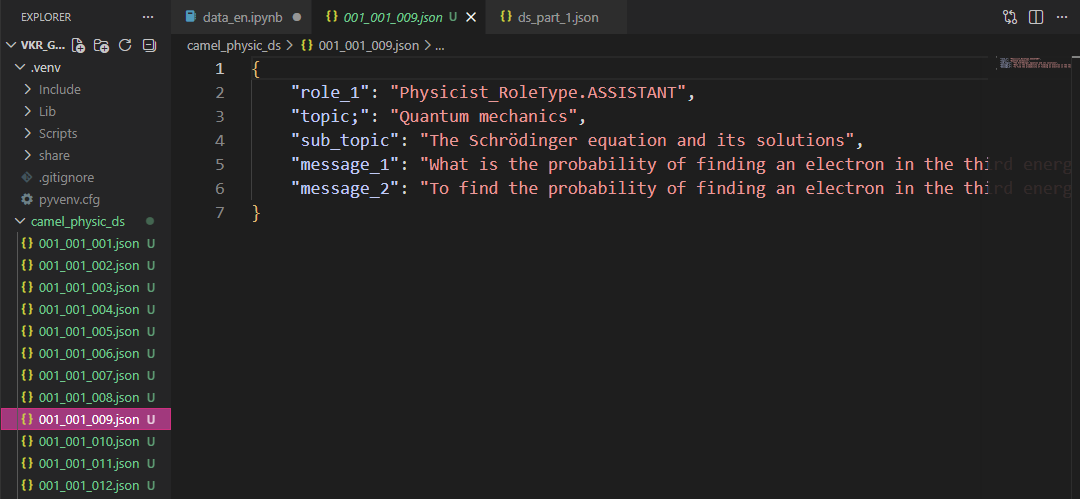

```qq
sub_topic - тема

message 1 - вопрос 

message 2 - подробное решение / объяснение + ответ
```

Сначала лучше соединить их в один файл:

In [24]:
folder_path = 'camel_physic_ds'

# список всех .json в папке
json_files = [f for f in os.listdir(folder_path) if f.endswith('.json')]

all_data = []

# tqdm для логирования
for file_name in tqdm(json_files, desc='Обработка файлов..'):
    file_path = os.path.join(folder_path, file_name)
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        all_data.append(data)

# сохранение
with open('camel_physics.json', 'w', encoding='utf-8') as f:
    json.dump(all_data, f, ensure_ascii=False, indent=2)

Обработка файлов..: 100%|██████████| 20000/20000 [01:29<00:00, 222.59it/s]


In [3]:
camel = pd.read_json('data\camel_physics.json')
camel

,role_1,topic;,sub_topic,message_1,message_2
0,Physicist_RoleType.ASSISTANT,Quantum mechanics,The Schrödinger equation and its solutions,What is the probability of finding a particle ...,To find the probability of finding a particle ...
1,Physicist_RoleType.ASSISTANT,Quantum mechanics,The Schrödinger equation and its solutions,What is the time-independent Schrödinger equat...,The time-independent Schrödinger equation is a...
2,Physicist_RoleType.ASSISTANT,Quantum mechanics,The Schrödinger equation and its solutions,Determine the wave function and energy eigenva...,To determine the wave function and energy eige...
3,Physicist_RoleType.ASSISTANT,Quantum mechanics,The Schrödinger equation and its solutions,What are the possible energy levels and wave f...,"To solve this problem, we need to apply the ti..."
4,Physicist_RoleType.ASSISTANT,Quantum mechanics,The Schrödinger equation and its solutions,If a particle is located in a one-dimensional ...,"Yes, I can help you find the possible energy l..."
...,...,...,...,...,...
19995,Physicist_RoleType.ASSISTANT,Biophysics,Modeling the dynamics of protein-protein aggre...,"""How can we use mathematical modeling to deter...",To use mathematical modeling to determine the ...
19996,Physicist_RoleType.ASSISTANT,Biophysics,Modeling the dynamics of protein-protein aggre...,What are the physical mechanisms that govern t...,The physical mechanisms that govern the dynami...
19997,Physicist_RoleType.ASSISTANT,Biophysics,Modeling the dynamics of protein-protein aggre...,What is the impact of external physical factor...,"The impact of external physical factors, such ..."
19998,Physicist_RoleType.ASSISTANT,Biophysics,Modeling the dynamics of protein-protein aggre...,How can we use mathematical modeling to predic...,Mathematical modeling can be a powerful tool f...


  "instruction": "",                    # Задача/вопрос пользователя


In [4]:
camel = camel.rename(columns = {'message_1': 'instruction', 'message_2': 'output'})
camel['input'] = ''
camel

,role_1,topic;,sub_topic,instruction,output,input
0,Physicist_RoleType.ASSISTANT,Quantum mechanics,The Schrödinger equation and its solutions,What is the probability of finding a particle ...,To find the probability of finding a particle ...,
1,Physicist_RoleType.ASSISTANT,Quantum mechanics,The Schrödinger equation and its solutions,What is the time-independent Schrödinger equat...,The time-independent Schrödinger equation is a...,
2,Physicist_RoleType.ASSISTANT,Quantum mechanics,The Schrödinger equation and its solutions,Determine the wave function and energy eigenva...,To determine the wave function and energy eige...,
3,Physicist_RoleType.ASSISTANT,Quantum mechanics,The Schrödinger equation and its solutions,What are the possible energy levels and wave f...,"To solve this problem, we need to apply the ti...",
4,Physicist_RoleType.ASSISTANT,Quantum mechanics,The Schrödinger equation and its solutions,If a particle is located in a one-dimensional ...,"Yes, I can help you find the possible energy l...",
...,...,...,...,...,...,...
19995,Physicist_RoleType.ASSISTANT,Biophysics,Modeling the dynamics of protein-protein aggre...,"""How can we use mathematical modeling to deter...",To use mathematical modeling to determine the ...,
19996,Physicist_RoleType.ASSISTANT,Biophysics,Modeling the dynamics of protein-protein aggre...,What are the physical mechanisms that govern t...,The physical mechanisms that govern the dynami...,
19997,Physicist_RoleType.ASSISTANT,Biophysics,Modeling the dynamics of protein-protein aggre...,What is the impact of external physical factor...,"The impact of external physical factors, such ...",
19998,Physicist_RoleType.ASSISTANT,Biophysics,Modeling the dynamics of protein-protein aggre...,How can we use mathematical modeling to predic...,Mathematical modeling can be a powerful tool f...,


In [5]:
camel = camel.drop(columns = ['role_1', 'topic;', 'sub_topic'])
camel

,instruction,output,input
0,What is the probability of finding a particle ...,To find the probability of finding a particle ...,
1,What is the time-independent Schrödinger equat...,The time-independent Schrödinger equation is a...,
2,Determine the wave function and energy eigenva...,To determine the wave function and energy eige...,
3,What are the possible energy levels and wave f...,"To solve this problem, we need to apply the ti...",
4,If a particle is located in a one-dimensional ...,"Yes, I can help you find the possible energy l...",
...,...,...,...
19995,"""How can we use mathematical modeling to deter...",To use mathematical modeling to determine the ...,
19996,What are the physical mechanisms that govern t...,The physical mechanisms that govern the dynami...,
19997,What is the impact of external physical factor...,"The impact of external physical factors, such ...",
19998,How can we use mathematical modeling to predic...,Mathematical modeling can be a powerful tool f...,


In [6]:
camel.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   instruction  20000 non-null  str  
 1   output       20000 non-null  str  
 2   input        20000 non-null  str  
dtypes: str(3)
memory usage: 47.6 MB


In [8]:
camel.to_json('data/camel2.json', orient='records', force_ascii=False, indent=4)

## [allenai/sciq](https://huggingface.co/datasets/allenai/sciq)

In [9]:
allenai = load_dataset("allenai/sciq")
allenai

c:\Users\aaron\vkr_tsa\project\vkr_gen_model\.venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\aaron\.cache\huggingface\hub\datasets--allenai--sciq. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating test split: 100%|██████████| 1000/1000 [00:00<00:00, 41191.30 examples/s]


DatasetDict({
    train: Dataset({
        features: ['question', 'distractor3', 'distractor1', 'distractor2', 'correct_answer', 'support'],
        num_rows: 11679
    })
    validation: Dataset({
        features: ['question', 'distractor3', 'distractor1', 'distractor2', 'correct_answer', 'support'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['question', 'distractor3', 'distractor1', 'distractor2', 'correct_answer', 'support'],
        num_rows: 1000
    })
})

In [10]:
allenai = allenai['train'].to_pandas()
allenai

,question,distractor3,distractor1,distractor2,correct_answer,support
0,What type of organism is commonly used in prep...,viruses,protozoa,gymnosperms,mesophilic organisms,"Mesophiles grow best in moderate temperature, ..."
1,What phenomenon makes global winds blow northe...,tropical effect,muon effect,centrifugal effect,coriolis effect,Without Coriolis Effect the global winds would...
2,Changes from a less-ordered state to a more-or...,endothermic,unbalanced,reactive,exothermic,Summary Changes of state are examples of phase...
3,What is the least dangerous radioactive decay?,zeta decay,beta decay,gamma decay,alpha decay,All radioactive decay is dangerous to living t...
4,Kilauea in hawaii is the world’s most continuo...,magma,greenhouse gases,carbon and smog,smoke and ash,Example 3.5 Calculating Projectile Motion: Hot...
...,...,...,...,...,...,...
11674,The enzyme pepsin plays an important role in t...,lipids,protons,proteins,peptides,Protein A large part of protein digestion take...
11675,What remains a constant of radioactive substan...,acidity,temperature,volatility,rate of decay,The rate of decay of a radioactive substance i...
11676,"Terrestrial ecosystems, also known for their d...",substrates,bisomes,monomes,biomes,"Terrestrial ecosystems, also known for their d..."
11677,High explosives create shock waves that exceed...,turbulence,light speed,ion speed,supersonic,The modern day formulation of gun powder is ca...


```qq
question - вопрос
correct_answer - правильный ответ
support - объяснение 
```

In [11]:
allenai = allenai.drop(columns = ['distractor3', 'distractor1', 'distractor2'])
allenai

,question,correct_answer,support
0,What type of organism is commonly used in prep...,mesophilic organisms,"Mesophiles grow best in moderate temperature, ..."
1,What phenomenon makes global winds blow northe...,coriolis effect,Without Coriolis Effect the global winds would...
2,Changes from a less-ordered state to a more-or...,exothermic,Summary Changes of state are examples of phase...
3,What is the least dangerous radioactive decay?,alpha decay,All radioactive decay is dangerous to living t...
4,Kilauea in hawaii is the world’s most continuo...,smoke and ash,Example 3.5 Calculating Projectile Motion: Hot...
...,...,...,...
11674,The enzyme pepsin plays an important role in t...,peptides,Protein A large part of protein digestion take...
11675,What remains a constant of radioactive substan...,rate of decay,The rate of decay of a radioactive substance i...
11676,"Terrestrial ecosystems, also known for their d...",biomes,"Terrestrial ecosystems, also known for their d..."
11677,High explosives create shock waves that exceed...,supersonic,The modern day formulation of gun powder is ca...


In [ ]:
allenai = allenai.rename(columns = {'question': 'instruction', 'correct_answer': 'output', '': 'input'})